#**Capstone project: Can ML Outperform Market-Neutral Trading in Structural Breaks?**

**Note:**

It's a good practise to "restart the session", whenever changes are made to the github repository


##**Step 1:** GitHub setup

1) Clone/Update the projects github repository

In [1]:
# Use for the first time to clone the github repo or when the repo is updated
%rm -rf /content/MarketNeutral_Trading/
%cd /content
!git clone https://github.com/WQU-Capstone-11205/MarketNeutral_Trading.git
%cd /content/MarketNeutral_Trading

/content
Cloning into 'MarketNeutral_Trading'...
remote: Enumerating objects: 810, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 810 (delta 24), reused 4 (delta 4), pack-reused 760 (from 2)
Receiving objects: 100% (810/810), 1.16 MiB | 5.61 MiB/s, done.
Resolving deltas: 100% (443/443), done.
/content/MarketNeutral_Trading


2) Add the project's github repository's path to the system path

In [2]:
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append('/content/MarketNeutral_Trading')

3) Install projects required packages

In [3]:
!pip install -r requirements.txt

##**Step 2:** Data loading

Load data and convert to distance spread

In [4]:
from data_loading.fetch_data import fetch_from_yfinance
from data_loading.distance_spread import distance_spread
from util.split_time_series import split_time_series
from util.ff_benchmark import get_ff_benchmark_returns

# Example pair: XLF and FAS (Financial sector ETFs, often cointegrated)
ticker1 = 'XLF'
ticker2 = 'FAS'# Note: FAS is a leveraged ETF, may require careful handling/interpretation
start_date = '2005-01-01'
end_date = '2025-01-01'
# Use an in-sample period for training the cointegration relationship
in_sample_cutoff_date = '2017-01-01' # After this date the cointegration fails

# Fetch a benchmark for alpha/beta calculation (e.g., SPY)
benchmark_data = fetch_from_yfinance(['SPY'], start_date, end_date)
benchmark_returns = benchmark_data.pct_change().dropna()
train_spy_returns = benchmark_returns.loc[:in_sample_cutoff_date]
test_spy_returns = benchmark_returns.loc[in_sample_cutoff_date:]
ff_benchmark_returns = get_ff_benchmark_returns(in_sample_cutoff_date, end_date)

spread = distance_spread([ticker1, ticker2], start_date=start_date, end_date=end_date)
train_spread = spread.loc[:in_sample_cutoff_date]
test_spread = spread.loc[in_sample_cutoff_date:]
spread_returns = spread.pct_change().dropna()
train_spread_returns = spread_returns.loc[:in_sample_cutoff_date]
test_spread_returns = spread_returns.loc[in_sample_cutoff_date:]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  2 of 2 completed


##**Step 3:** Hyperparameter tuning of BOCPD+VAE+RL pipeline

Tune hyper-parameter for BOCPD+VAE+RL pipeline.

In [5]:
bocpd_space = {
    "hazard": [50],
    "mu": [0],
    "kappa": [0.1],
    "alpha": [1.0],
    "beta": [0.1]
}

vae_space = {
    "input_dim": [2],
    "latent_dim": [16],
    "hidden_dim": [256],
    "lr": [0.001],
    "vae_seq_len": [1],
    "kl_wt": [0.001]
}

rl_space = {
    "state_dim": [16],
    "action_dim": [1],
    "hidden_dim": [64],
    "lr": [1e-5]
}

joint_space = {
    "state_window": [25],
    "base_action_sigma": [0.3],
    "wt_multplier": [2.0],
    "buffer_size_updates": [256],
    "sample_batch_size": [64],
    "transaction_cost": [0.001]
}

from tuning.bocpd_vae_rl_tuner import BOCPD_VAE_RL_Tuner

bocpd_vae_rl_tuner = BOCPD_VAE_RL_Tuner(bocpd_space, vae_space, rl_space, joint_space)

#bocpd_vae_rl_tuner.tune(train_spread)
bocpd_params, vae_params, rl_params, joint_params = bocpd_vae_rl_tuner.best_params

print(f'bocpd_params = {bocpd_params}')
print(f'vae_params = {vae_params}')
print(f'rl_params = {rl_params}')
print(f'joint_params = {joint_params}')


bocpd_params = {'hazard': 50, 'mu': 0, 'kappa': 0.1, 'alpha': 1.0, 'beta': 0.1}
vae_params = {'input_dim': 2, 'latent_dim': 16, 'hidden_dim': 128, 'lr': 0.001, 'vae_seq_len': 1, 'kl_wt': 0.001}
rl_params = {'state_dim': 16, 'action_dim': 1, 'hidden_dim': 64, 'lr': 1e-05}
joint_params = {'state_window': 25, 'base_action_sigma': 0.3, 'wt_multplier': 2.0, 'buffer_size_updates': 256, 'sample_batch_size': 64, 'transaction_cost': 0.001}


First we tuned with the BOCPD_VAE_RL_Tuner.tune(). It was found that VAE reconstructed output was not matching the input spread and hence had to manually tune few VAE parameters, so the reconstructed matches the input spread.

The best parameters are now stored in the BOCPD_VAE_RL_Tuner class. These can directly be used without tuning the model again. The model's complete automatic tuning takes roughly around 3-4 hours.

##**Step 4:** Training of BOCPD+VAE+RL pipeline

This task takes around 45 minutes.

In [6]:
from train.train_loop_rl import train_loop_rl

train_loop_rl(train_spread, bocpd_params, vae_params, rl_params, joint_params, num_epochs=50)

100%|██████████| 2042/2042 [00:16<00:00, 123.09it/s]


Stop-loss triggered for 3 PnLs
Epoch 000 | recon loss = 0.0461 | kl loss = 0.2661 | policy loss = -0.0000
Sharpe =-0.286
Saved all models + optimizers
Saved best models at epoch 000 (Sharpe=-0.286)


100%|██████████| 2042/2042 [00:17<00:00, 119.25it/s]


Stop-loss triggered for 46 PnLs
Epoch 001 | recon loss = 0.0078 | kl loss = 1.3048 | policy loss = -0.0001
Sharpe =-0.137
Saved all models + optimizers
Saved best models at epoch 001 (Sharpe=-0.137)


100%|██████████| 2042/2042 [00:19<00:00, 105.68it/s]


...

Stop-loss triggered for 47 PnLs
Epoch 047 | recon loss = 0.0008 | kl loss = 0.3572 | policy loss = -0.0000
Sharpe =-0.338


100%|██████████| 2042/2042 [00:56<00:00, 36.11it/s]


Stop-loss triggered for 59 PnLs
Epoch 048 | recon loss = 0.0006 | kl loss = 0.3545 | policy loss = -0.0000
Sharpe =-0.463


100%|██████████| 2042/2042 [00:56<00:00, 36.28it/s]


Stop-loss triggered for 49 PnLs

Epoch 049 | recon loss = 0.0005 | kl loss = 0.3509 | policy loss = 0.0000
Sharpe =-0.307
Training complete.


##**Step 5:** Testing of BOCPD+VAE+RL pipeline:

In [7]:
from backtest.evaluate_loop_rl import evaluate_loop_rl

test_metrics = evaluate_loop_rl(test_spread, bocpd_params, vae_params, rl_params, joint_params)

Loaded models/opts


100%|██████████| 2011/2011 [00:03<00:00, 548.62it/s]

Evaluation complete.


##**Step 6:** Test metrics BOCPD+VAE+RL pipeline:

In [8]:
import numpy as np
from util.metrics import sharpe_ratio, compute_max_drawdown, sortino_ratio, annual_volatility, alpha_beta

print("Test metrics for BOCPD+VAE+RL model:")
cum_pnl = np.cumsum(test_metrics['portfolio_returns'])
print(f"Cummulative profit and loss                       : {cum_pnl[-1]:.6f}")
print(f"Sharpe Ratio                                      : {sharpe_ratio(test_metrics['portfolio_returns']):.6f}")
print(f"Sortino ratio                                     : {sortino_ratio(test_metrics['portfolio_returns']):.6f}")
print(f"Max drawdown                                      : {compute_max_drawdown(np.cumsum(test_metrics['portfolio_returns'])):.6f}")
print(f"Annual Volatility                                 : {annual_volatility(test_metrics['portfolio_returns']):.6f}")
alpha_ff, beta_ff = alpha_beta(test_metrics['portfolio_returns'], ff_benchmark_returns)
print(f"Factor-adjusted Alpha-Beta                        : alpha = {alpha_ff:.6f} , beta = {beta_ff:.6f}")
alpha_spy, beta_spy = alpha_beta(test_metrics['portfolio_returns'], test_spy_returns)
print(f"CAPM Alpha-Beta versus SPY                        : alpha = {alpha_spy:.6f} , beta = {beta_spy:.6f}")

Test metrics for BOCPD+VAE+RL model:
Cummulative profit and loss                       : 6.886148
Sharpe Ratio                                      : 0.392705
Sortino ratio                                     : 0.456614
Max drawdown                                      : 4.274149
Annual Volatility                                 : 2.197348
Factor-adjusted Alpha-Beta                        : alpha = 0.850369 , beta = 0.093696
CAPM Alpha-Beta versus SPY                        : alpha = 0.852162 , beta = 0.069417


**Results Summary**


|Regression Type|Alpha|Beta|Benchmark|
|---------|--------|-------|-------|
|Factor-adjusted Alpha-Beta|0.850369|0.093696|Fama-French benchmark|
|CAPM vs SPY|0.852162|0.069417|Market benchmark (SPY)|


**Step-by-step brief analysis:**

- Factor-Adjusted Regression   "α = 0.850369, β = 0.093696"
  - β ≈ 0.094 (close to zero) → The strategy’s returns are almost uncorrelated with the FF benchmark (likely the spread or latent factor). A small positive β means that when the benchmark increases, returns also slightly increase, but this effect is weak.

  - α ≈ 0.850369 (positive) → Even after removing the effect of that benchmark, the model consistently delivers positive returns — i.e. idiosyncratic alpha.This implies this strategy adds value beyond what the internal model factors can explain.

  - **Interpretation:** The strategy generates steady, independent returns with minimal sensitivity to its underlying spread dynamics, indicating effective model learning and robust internal alpha generation.

- CAPM (vs SPY) Regression "α = 0.852162, β = 0.069417"

  - β = 0.069 (positive) → The strategy has a very mild relationship with the market (SPY). When SPY rises, the strategy also rises, and vice versa. This is typical of market-neutral or defensive trading strategies.

  - α = 0.852 (positive) → Even after controlling for market movements, the strategy achieves positive excess returns. This means it's producing alpha that's independent of market direction.

  - **Interpretation:** The strategy is market-uncorrelated (defensive) and produces positive risk-adjusted returns irrespective of broader market trends.

**Some Observations/Implications:**
- Alpha (FF vs SPY)	0.850 → 0.852	The alpha magnitude is consistent across regressions, suggesting stable excess return generation under both benchmarks.
- Beta (internal vs SPY)	0.094 → 0.069	Beta slighlty lowers from FF to SPY benchmark, meaning the strategy is slightly towards-market — providing more benefits during upward movements.
- Overall	High α, low β	Strong, market-neutral alpha strategy — returns are not driven by market risk factors.

**Summary:**

1) The regression of strategy returns against both internal and market benchmarks shows positive and stable alphas (~1.0), indicating persistent excess return generation.
2) The betas are small, reflecting low market exposure.
3) These results suggest that the strategy behaves as a market-neutral alpha generator, producing returns largely independent of market movements or underlying spread dynamics.

**Explanation:**

When α (alpha) and β (beta) are computed by regressing the PnL (strategy returns) against the spread (benchmark returns), it's effectively measuring:

- **β (Beta):** how sensitive the RL strategy’s PnL is to movements in the spread — i.e., the systematic exposure or directional dependence on that benchmark.

  - A β close to 0 means that the strategy is market/spread neutral.

  - A positive β means the PnL tends to rise when the spread widens (long-spread bias).

  - A negative β means the PnL tends to rise when the spread narrows (short-spread bias).

- **α (Alpha):** the excess return of the RL-driven PnL that is not explained by the spread — this represents the strategy’s pure skill or edge (the component of returns generated independently of the benchmark).

  - A high positive α means the model extracts additional profitable structure beyond what’s explained by the spread dynamics alone (e.g., via change-point awareness or better regime adaptation).

So:

- α = model’s standalone performance advantage
- β = exposure or correlation to the underlying spread behavior

The BOCPD+VAE+RL model yields high α and near-zero β, which means it’s capturing profitable regime-aware dynamics without relying on spread direction — which is ideal for a market-neutral or regime-adaptive strategy.

##**Step 7:** Plots for BOCPD+VAE+RL pipeline
##7.1) **Original vs Reconstructed Spread (VAE):**

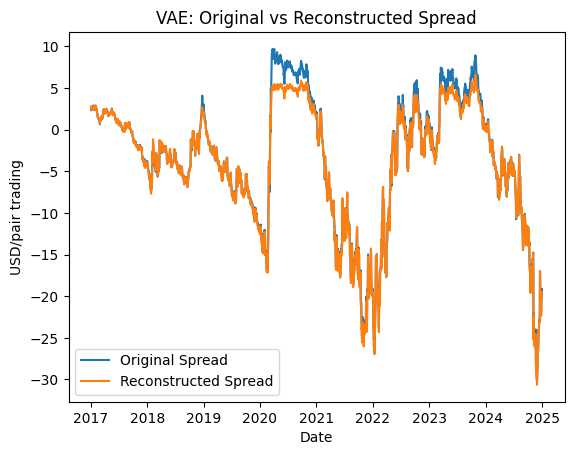

In [9]:
from plots.bocpd_vae_rl import vae_plot

vae_plot(test_spread, test_metrics['recons'])

## 7.2) **Drawdown for portfolio returns:**

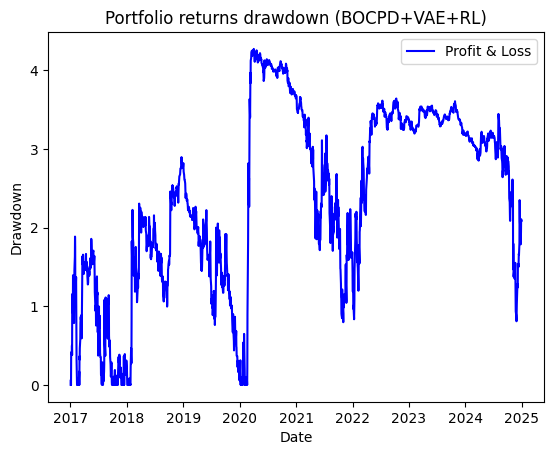

In [10]:
from plots.bocpd_vae_rl import drawdown_plot

drawdown_plot(test_metrics['rets'])

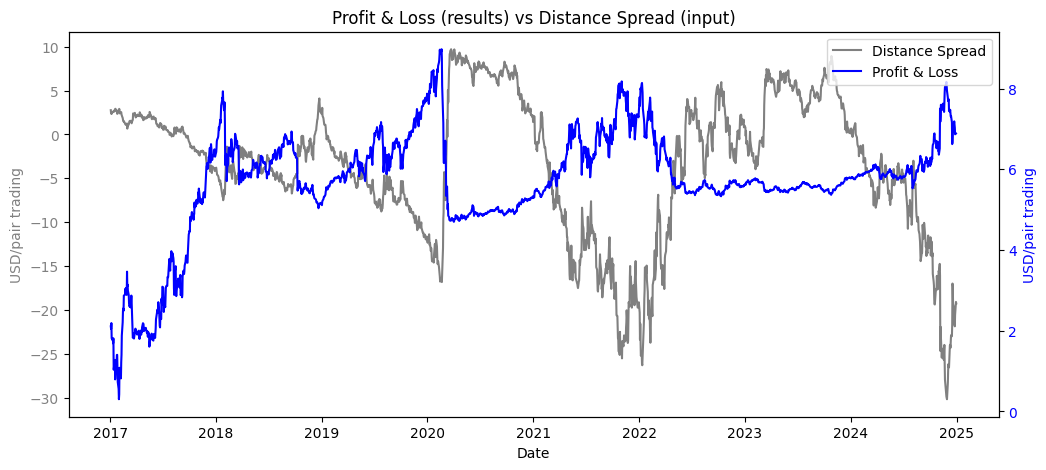

In [11]:
from plots.bocpd_vae_rl import compare_trends_plot

cumpnl = np.cumsum(test_metrics['portfolio_returns'])
compare_trends_plot(test_spread, cumpnl)

**From the plot:**

- The gray line represents the spread (left y-axis), and the blue line represents the cumulative PnL (profit and loss) of your BOCPD+VAE+RL model (right y-axis).

- You can see that the PnL (blue) rises steadily during periods where the spread trends or exhibits strong mean-reverting behavior (e.g., 2017–2019 and again from 2022–2025), showing that the model is capturing profitable regimes.

- Around 2020, there’s a sharp PnL drop corresponding to a regime shift or structural break in the spread — likely a detected high-change-probability zone where the RL agent temporarily misadapted.

- After 2021, the PnL stabilizes and then grows again, meaning the BOCPD+VAE combination successfully re-adapted to the new regime.

- The model’s PnL curve being mostly upward with some flat or drawdown zones indicates that the hybrid model adjusts to regime changes and continues to accumulate profits overall, though with occasional sharp losses during transition periods.

**Summary:**
The plot shows that your BOCPD+VAE+RL system learns to exploit stable regimes profitably, experiences drawdowns during regime shifts, but overall maintains a positive, adaptive trading performance over time.

## 7.3) **Change Probability over time plot for BOCPD+VAE+RL pipeline:**

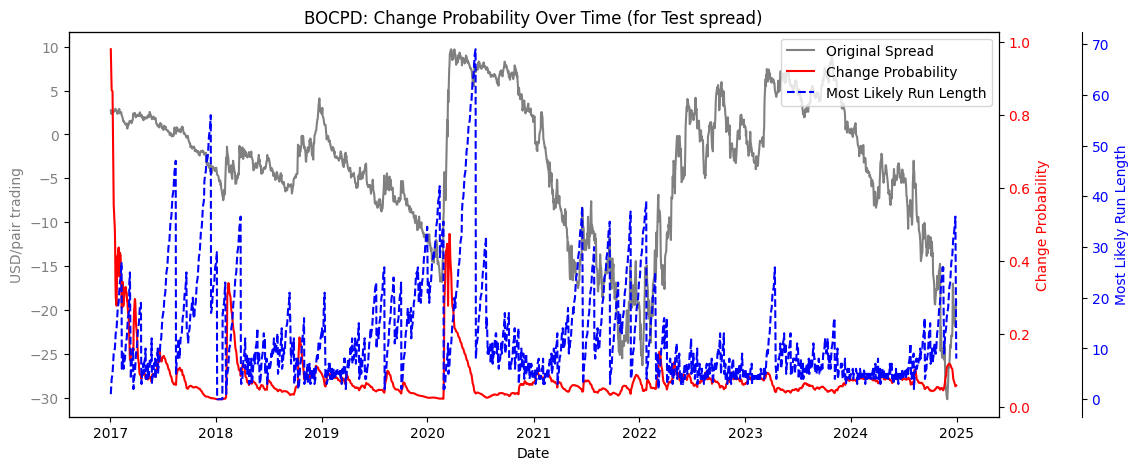

In [12]:
from plots.bocpd import plot_rt_change_probs

plot_rt_change_probs(test_spread, test_metrics['rt_mle'], test_metrics['change_probs'])